In [159]:
# @title {"single-column":true,"display-mode":"form"}

DATASET = "Cancer" # @param ["Cancer", "Somatic + Germline"]

OUTPUT_TYPE = "Proportions" # @param ["Counts", "Proportions"]

MIN_COUNT = 5 # @param {type:"integer"}


In [161]:
import pandas as pd
import re
import httpimport

with httpimport.github_repo("glygener", "colab-notebooks", ref="main"):
    from glygen import GlyGenDownloader

ggdl = GlyGenDownloader(glygen_data_version="v-2.10.1")

In [162]:
germ_files = "human_protein_mutation_germline_glycoeffect.csv"
som_files = "human_protein_mutation_somatic_glycoeffect.csv"
cancer_files = "human_protein_mutation_cancer_glycoeffect.csv"

params = {
    "usecols": [
        "uniprotkb_canonical_ac",
        "aa_pos",
        "ref_aa",
        "alt_aa",
        "do_id",
        "effect"
    ],
    "dropdups": True,
    "notna": ["do_id"]
}

germ = ggdl.dataframe(germ_files, **params)
som = ggdl.dataframe(som_files, **params)
cancer = ggdl.dataframe(cancer_files, **params)

Download human_protein_mutation_germline_glycoeffect.csv...
Download progress: 229MB [00:19, 12.0MB/s]                           
Download human_protein_mutation_germline_glycoeffect.csv... done (229.14 MB).
Constructed DataFrame:

<class 'pandas.core.frame.DataFrame'>
Index: 8049 entries, 0 to 9753
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   uniprotkb_canonical_ac  8049 non-null   object 
 1   aa_pos                  8049 non-null   int64  
 2   ref_aa                  8049 non-null   object 
 3   alt_aa                  7586 non-null   object 
 4   do_id                   8049 non-null   float64
 5   effect                  8049 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 440.2+ KB

Download human_protein_mutation_somatic_glycoeffect.csv...
Download progress: 92.8MB [00:09, 10.2MB/s]                            
Download human_protein_mutation_somatic_glycoef

In [163]:
"""Human Disease Ontology Mapping File [v2026-02-28] """

url = "https://raw.githubusercontent.com/glygener/colab-notebooks/main/supplementary_file_5/HumanDO.tsv"

mapping_df = pd.read_csv(url, sep="\t")

print(mapping_df.head())

             id                                              label  \
0  DOID:0040058   1,4-phenylenediamine allergic contact dermatitis   
1  DOID:0040069  1-chloro-2,4-dinitrobenzene allergic contact d...   
2  DOID:0112248  17-beta hydroxysteroid dehydrogenase 3 deficiency   
3  DOID:0040079      2,4-dinitrophenyl allergic contact dermatitis   
4  DOID:0111453                 2-aminoadipic 2-oxoadipic aciduria   

                      subClassOf  
0    allergic contact dermatitis  
1    allergic contact dermatitis  
2          pseudohermaphroditism  
3    allergic contact dermatitis  
4  amino acid metabolic disorder  


In [149]:
columns = [
    "uniprotkb_canonical_ac",
    "aa_pos",
    "ref_aa",
    "alt_aa",
    "do_id",
    "effect"
]

germ = germ[columns]
som = som[columns]
cancer = cancer[columns]

def clean_dataframe(df):
    df = df.dropna().copy() # Avoid SettingWithCopyWarning
    df["do_id"] = df["do_id"].astype(int)
    df = df.drop_duplicates()
    return df

cancer = clean_dataframe(cancer)

som_germ = pd.concat([som, germ], ignore_index=True)
som_germ = clean_dataframe(som_germ)

print(cancer.head)
print(som_germ.head)

<bound method NDFrame.head of        uniprotkb_canonical_ac  aa_pos ref_aa alt_aa  do_id  \
0                    Q9Y4B4-1    1085      S      F   4159   
1                    Q9Y4B4-1    1085      S      F   4159   
2                    P12882-1     594      A      S    363   
3                    Q9Y2L6-1     627      S      L  10534   
4                    Q86WB7-1      68      K      N   1324   
...                       ...     ...    ...    ...    ...   
117716               Q96JC4-1     466      T      K   9256   
117717               P11532-1    2551      T      M   1324   
117718               Q92793-1      32      S      L   4362   
117719               Q12860-1     505      T      M   9256   
117720               P12259-1    1308      S      I    263   

                     effect  
0       n-glyco-sequon-loss  
1         o-glyco-site-loss  
2       n-glyco-sequon-gain  
3         o-glyco-site-loss  
4       n-glyco-sequon-gain  
...                     ...  
117716    o-gly

In [164]:
mapping_df["id_int"] = (
    mapping_df["id"]
    .str.replace("DOID:", "", regex=False)
    .astype(int)
)

do_mapping = dict(
    zip(mapping_df["id_int"], mapping_df["subClassOf"])
)

cancer["do_name"] = cancer["do_id"].map(do_mapping)
som_germ["do_name"] = som_germ["do_id"].map(do_mapping)

In [165]:
def clean_data(df):
    """Clean and filter disease name data."""
    df["do_name"] = df["do_name"].fillna("").astype(str)

    invalid_terms = [""]
    df = df[~df["do_name"].str.lower().isin(invalid_terms)]

    return df

In [166]:
cancer = clean_data(cancer)
som_germ = clean_data(som_germ)

In [167]:
def categorize_cancer(text):
    """Categorize diseases into cancer types."""
    text = text.lower()

    # --- First: is it cancer at all? ---
    if not re.search(
        r"cancer|carcinoma|tumou?r|neoplasm|leukemia|lymphoma|sarcoma",
        text
    ):
        return "Other"

    # --- Nervous system ---
    if re.search(
        r"brain|central nervous system|cns|glioma|astrocytoma|infratentorial|retina|retinal",
        text
    ):
        return "Nervous System Cancer"

    # --- Hematologic ---
    if re.search(
        r"leukemia|lymphoma|myeloma|bone marrow|hematologic|blood cancer",
        text
    ):
        return "Hematologic Cancer"

    # --- Gastrointestinal ---
    if re.search(
        r"stomach|gastric|intestinal|colon|colorectal|large intestine|small intestine|gi|gastrointestinal",
        text
    ):
        return "Gastrointestinal Cancer"

    # --- Hepatobiliary ---
    if re.search(
        r"liver|hepatic|hepatobiliary|bile duct|cholangiocarcinoma",
        text
    ):
        return "Hepatobiliary Cancer"

    # --- Respiratory ---
    if re.search(
        r"lung|pulmonary|bronchial|respiratory",
        text
    ):
        return "Respiratory Cancer"

    # --- Endocrine ---
    if re.search(
        r"thyroid|adrenal|pituitary|endocrine|parathyroid",
        text
    ):
        return "Endocrine Cancer"

    # --- Skin ---
    if re.search(
        r"skin|melanoma|cutaneous|integumentary",
        text
    ):
        return "Skin Cancer"

    # --- Renal / Urinary ---
    if re.search(
        r"kidney|renal|bladder|urinary|urothelial",
        text
    ):
        return "Renal/Urinary Cancer"

    # --- Female reproductive ---
    if re.search(
        r"breast|ovarian|ovary|uterine|endometrial|cervical|female reproductive",
        text
    ):
        return "Female Reproductive Cancer"

    # --- Male reproductive ---
    if re.search(
        r"prostate|testicular|testis|male reproductive",
        text
    ):
        return "Male Reproductive Cancer"

    # --- Pancreatic ---
    if re.search(r"pancrea", text):
        return "Pancreatic Cancer"

    # --- Fallback ---
    return "Unspecified Cancer"


In [168]:
def categorize_noncancer(text):
    """Categorize diseases into broad disease classes."""
    text = text.lower()

    if re.search(
        r"cancer|carcinoma|tumor|neoplasm|leukemia|lymphoma|sarcoma",
        text
    ):
        return "Cancer-Risk"

    elif re.search(
        r"neuro|alzheimer|parkinson|epilepsy|ataxia|dementia|sclerosis|migraine|cmt|charcot",
        text
    ):
        return "Neurological"

    elif re.search(
        r"cardio|heart|cardiomyopathy|arrhythmia|aortic|atrial|vascular|artery|hypertension|thromb|sinoatrial",
        text
    ):
        return "Cardiovascular"

    elif re.search(
        r"diabetes|metabolic|glycogen|lipid|cholesterol|endocrin|thyroid|metabolism",
        text
    ):
        return "Metabolic"

    elif re.search(
        r"immune|autoimmune|inflammatory|immunodeficiency|lupus",
        text
    ):
        return "Immune"

    elif re.search(
        r"syndrome|congenital|developmental|intellectual|microcephaly|dysplasia|cranio|acro|syndactyly",
        text
    ):
        return "Developmental"

    elif re.search(
        r"muscular|dystrophy|myopathy|skeletal|bone|osteoporosis",
        text
    ):
        return "Musculoskeletal"

    elif re.search(
        r"kidney|renal|hypogonadism|spermatogenic|nephro",
        text
    ):
        return "Renal"

    elif re.search(
        r"deafness|hearing|macular|vision|retina|blindness",
        text
    ):
        return "Sensory"

    elif re.search(
        r"anemia|spherocytosis|hemoglob|sickle|protein s|protein c",
        text
    ):
        return "Hematological"

    elif re.search(
        r"hereditary|familial",
        text
    ):
        return "Hereditary"

    else:
        return "Uncategorized"

In [169]:
if DATASET == "Cancer":
    df = cancer.copy()
    df["category"] = df["do_name"].apply(categorize_cancer)

else:
    df = som_germ.copy()
    df["category"] = df["do_name"].apply(categorize_noncancer)

In [170]:
counts = (
    df.groupby(["effect", "category"])
      .size()
      .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1) >= MIN_COUNT]

proportions = counts.div(counts.sum(axis=1), axis=0)

In [171]:
if OUTPUT_TYPE == "Counts":
    result = counts
else:
    result = proportions

result

category,Endocrine Cancer,Female Reproductive Cancer,Gastrointestinal Cancer,Hepatobiliary Cancer,Male Reproductive Cancer,Nervous System Cancer,Renal/Urinary Cancer,Respiratory Cancer,Skin Cancer,Unspecified Cancer
effect,,,,,,,,,,
n-glyco-sequon-gain,0.022522,0.170246,0.212625,0.030073,0.027591,0.058316,0.045880,0.117730,0.223259,0.091759
n-glyco-sequon-loss,0.026989,0.153485,0.232105,0.040835,0.033091,0.045999,0.047798,0.137135,0.171478,0.111085
o-glyco-site-loss,0.048650,0.156302,0.297313,0.026042,0.036791,0.051370,0.050578,0.093721,0.132611,0.106623


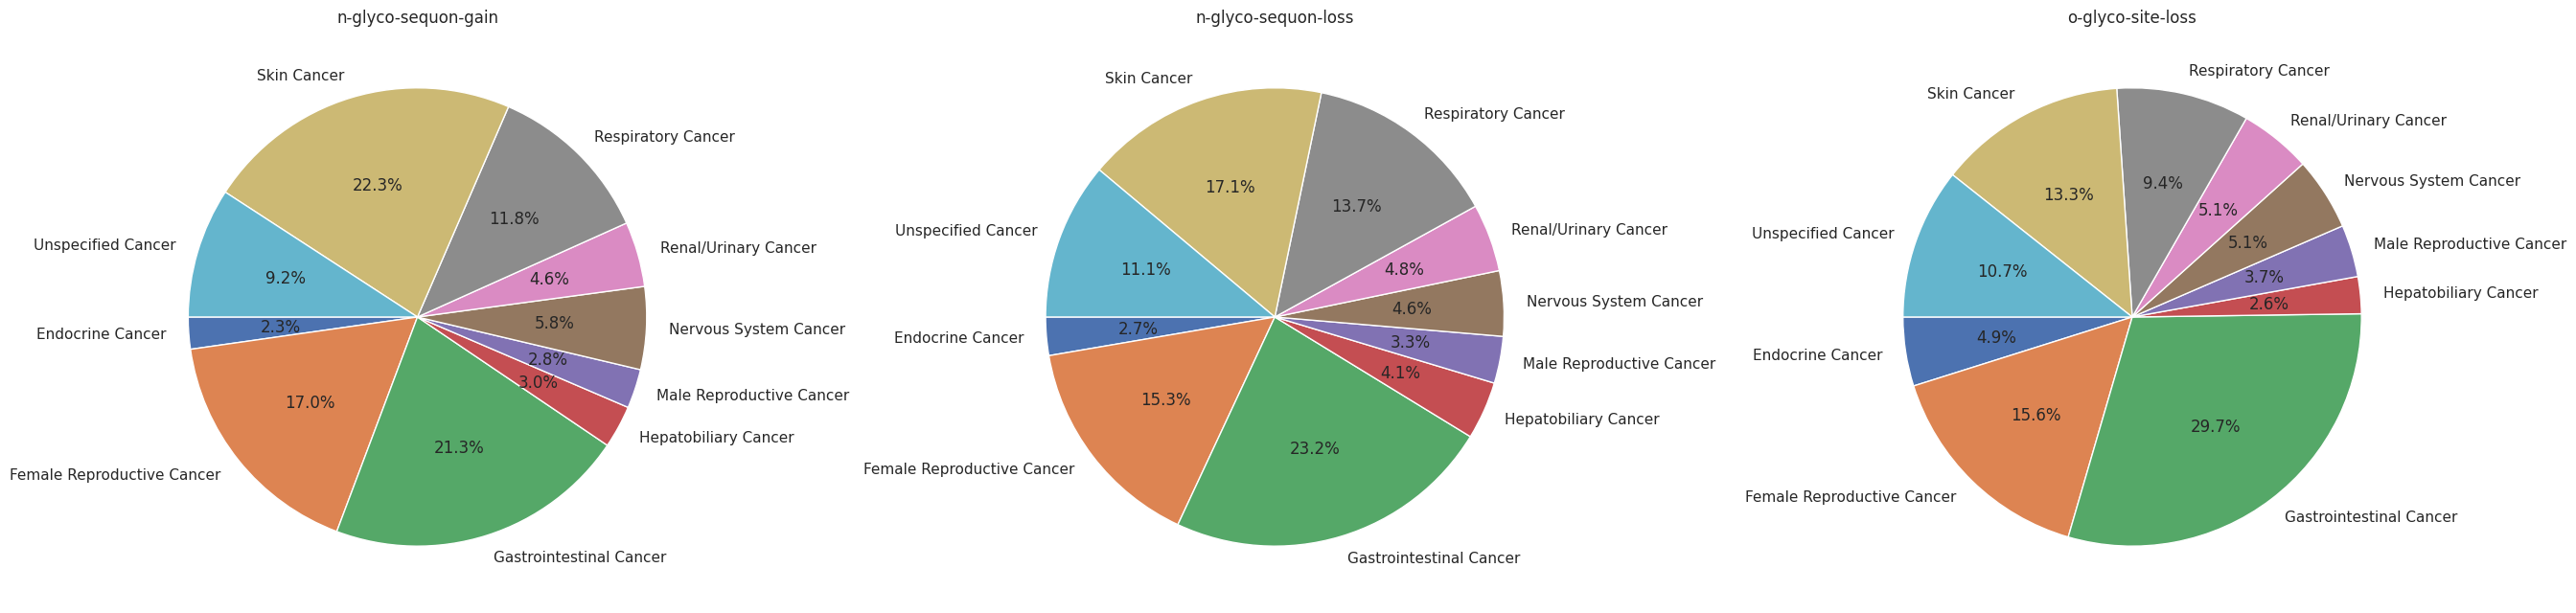

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_theme(style="white")
plot_df = proportions.copy()
n_effects = len(plot_df.index)

ncols = 3
nrows = math.ceil(n_effects / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(9 * ncols, 8 * nrows)
)

axes = axes.flatten()
for ax, effect in zip(axes, plot_df.index):
    values = plot_df.loc[effect]
    values = values[values > 0]
    ax.pie(
        values,
        labels=values.index,
        autopct="%1.1f%%",
        startangle=180,
    )
    ax.set_title(effect)
for ax in axes[n_effects:]:
    ax.axis("off")

plt.tight_layout()
plt.show()